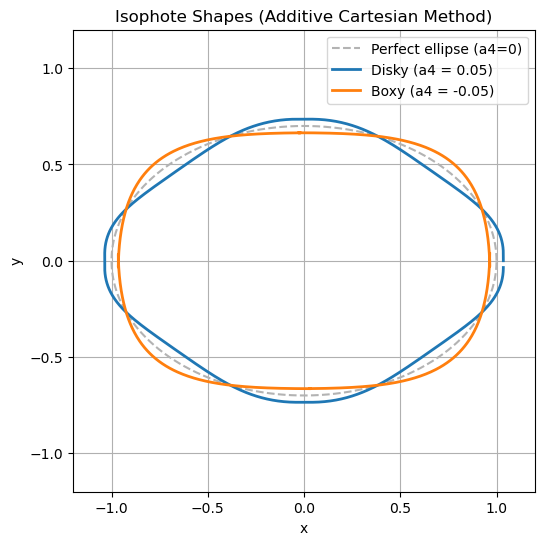

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup the phase/angle grid
theta = np.linspace(0, 2*np.pi, 1000)

# 2. Define the Base Ellipse in Cartesian coordinates
a = 1.0
b = 0.7
x_base = a * np.cos(theta)
y_base = b * np.sin(theta)

# 3. Define the Fourier offsets (r)
# We use alpha4 to match the "boxy/disky" logic
a4_disky = 0.05
a4_boxy  = -0.05

r_disky = a4_disky * np.cos(4 * theta)
r_boxy  = a4_boxy * np.cos(4 * theta)

def apply_radial_offset(x, y, r):
    """
    Applies a radial offset r to Cartesian coordinates x, y 
    using the quadrant-aware logic from the original code.
    """
    # Create copies to avoid overwriting the base arrays
    x_new = x.copy()
    y_new = y.copy()
    
    # The shift magnitude (splitting r into x and y components)
    s = r / np.sqrt(2.0)
    
    # Adjust X based on quadrant
    x_new[x > 0] += s[x > 0]
    x_new[x < 0] -= s[x < 0]
    
    # Adjust Y based on quadrant
    y_new[y > 0] += s[y > 0]
    y_new[y < 0] -= s[y < 0]
    
    return x_new, y_new

# 4. Generate the modified shapes
xd, yd = apply_radial_offset(x_base, y_base, r_disky)
xb, yb = apply_radial_offset(x_base, y_base, r_boxy)

# 5. Plotting
plt.figure(figsize=(6,6))
plt.plot(x_base, y_base, color='0.7', linestyle='--', label='Perfect ellipse (a4=0)')
plt.plot(xd, yd, label=f'Disky (a4 = {a4_disky})', lw=2)
plt.plot(xb, yb, label=f'Boxy (a4 = {a4_boxy})', lw=2)

plt.gca().set_aspect('equal')
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Isophote Shapes (Additive Cartesian Method)')
plt.grid(True)
plt.savefig("Astr797_hw2_problem3_revsied.png")
plt.show()